# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch
import pandas as pd
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(".."))
%load_ext autoreload
%autoreload 2
from src.utils import print_images, stratified_split


RANDOM_SEED = 1973

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## EDA

In [15]:
df = pd.read_csv("data/raw/fashion_mnist_subset.csv")
y = df["label"]
X = df.drop(columns=["label"])

# Verificar shape
print("X shape:", X.shape)  
print("y shape:", y.shape)
print("Labels:", np.unique(y))

np.save("data/raw/X_images.npy", X)
np.save("data/raw/y_labels.npy", y)

X shape: (25000, 784)
y shape: (25000,)
Labels: [0 1 2 3 4 5 6 7 8 9]


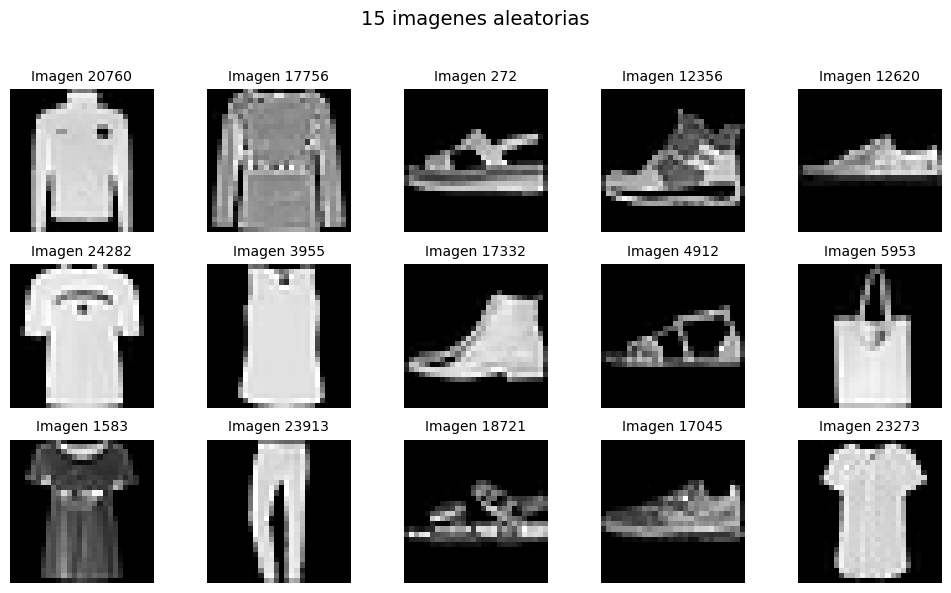

In [16]:
X = np.load("data/raw/X_images.npy")
y = np.load("data/raw/y_labels.npy")
N = 15

print_images(N, X, f"{N} imagenes aleatorias",RANDOM_SEED)

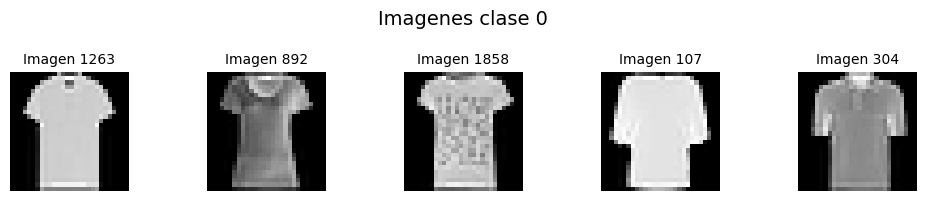

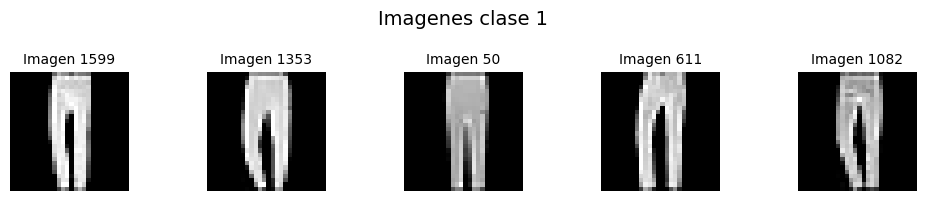

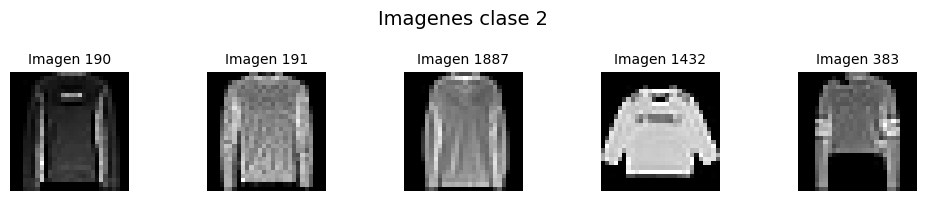

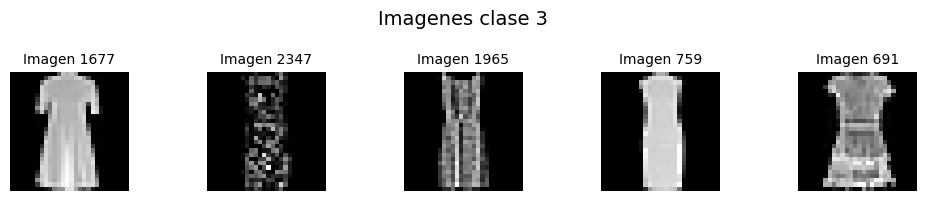

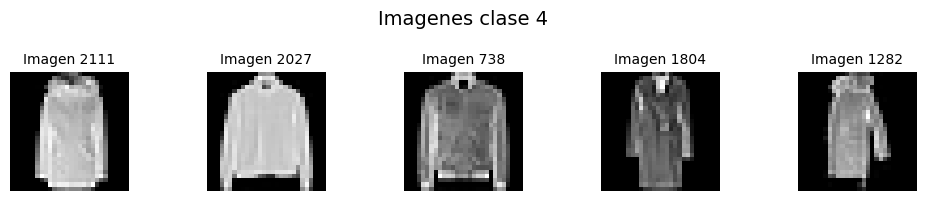

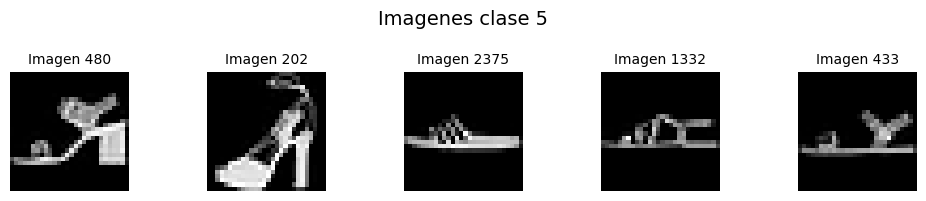

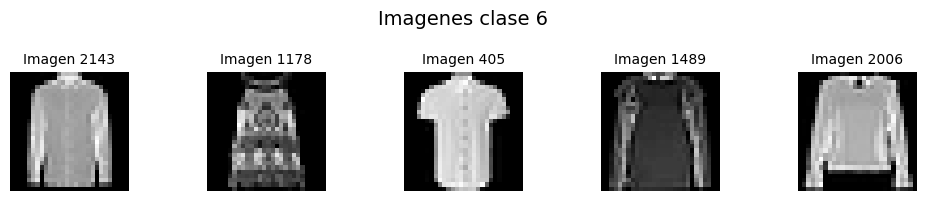

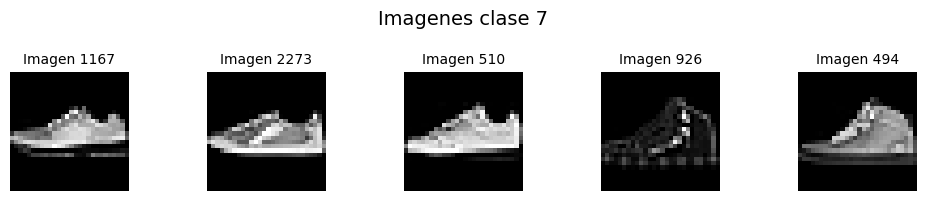

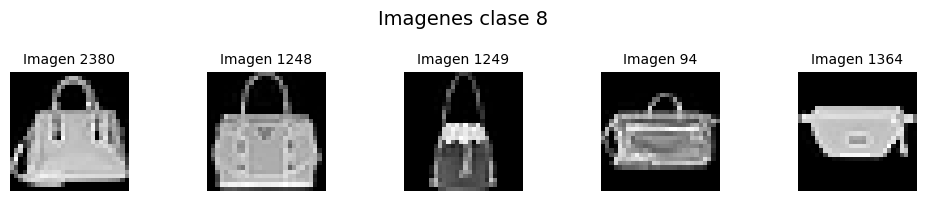

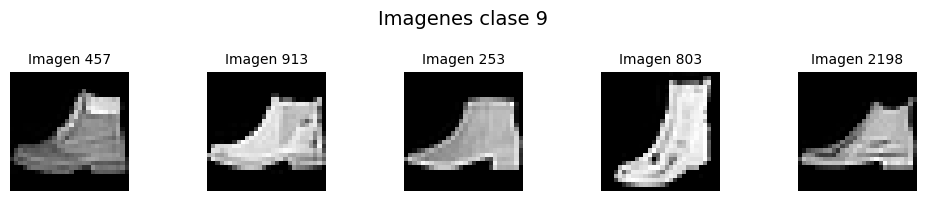

In [19]:
for i in np.unique(y):
    class_images = X[y == i]
    print_images(
        5,
        class_images,
        random_seed=RANDOM_SEED+i,
        title=f"Imagenes clase {i}"
    )

In [22]:
# Hago un split 80/20 manteniendo la misma proporcion de cada clase en train y validation

X_train, X_val, y_train, y_val = stratified_split(X, y, 0.8)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")

for label in np.unique(y):
    train_count = np.sum(y_train == label)
    val_count = np.sum(y_val == label)

    print(
        f"Clase {label}: "
        f"train={train_count}/{len(y_train)} ({train_count / len(y_train):.1%}), "
        f"val={val_count}/{len(y_val)} ({val_count / len(y_val):.1%})"
    )

np.save("data/preprocessed/X_train.npy", X_train)
np.save("data/preprocessed/X_val.npy", X_val)
np.save("data/preprocessed/y_train.npy", y_train)
np.save("data/preprocessed/y_val.npy", y_val)

Train size: 20000
Val size: 5000
Clase 0: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 1: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 2: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 3: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 4: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 5: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 6: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 7: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 8: train=2000/20000 (10.0%), val=500/5000 (10.0%)
Clase 9: train=2000/20000 (10.0%), val=500/5000 (10.0%)
